In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow.xgboost

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")
df.info()

Nombre de lignes : 7043
Nombre de colonnes : 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 

In [4]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [5]:
df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [7]:
df['TotalCharges'].isna().sum()

np.int64(0)

In [8]:
df['TotalCharges'].dtype


dtype('float64')

In [9]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


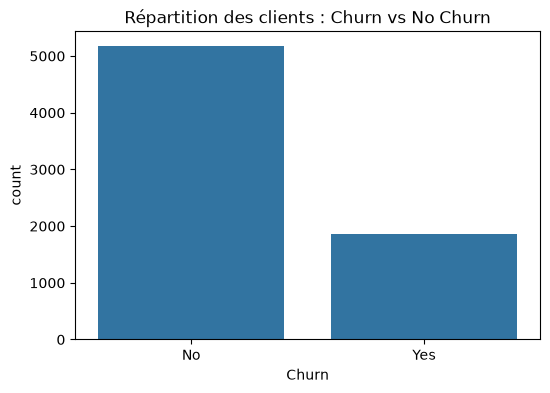

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title('Répartition des clients : Churn vs No Churn')
plt.show()

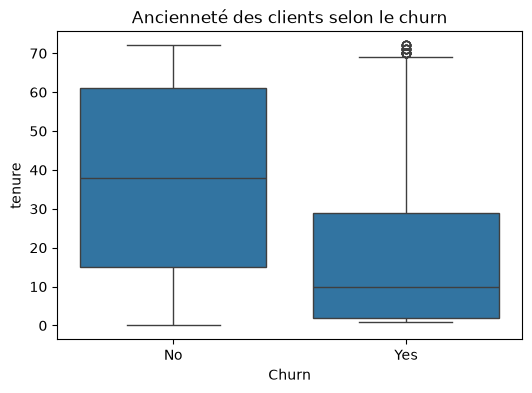

In [11]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Ancienneté des clients selon le churn')
plt.show()

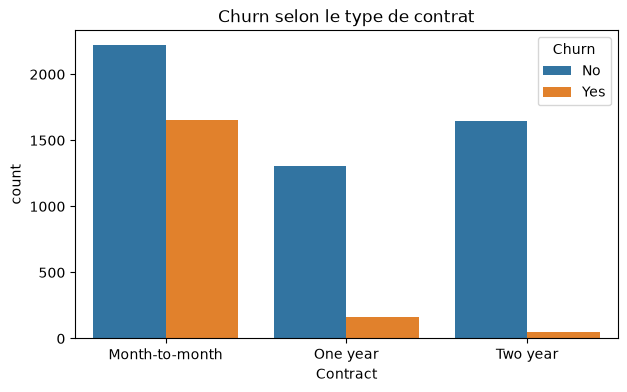

In [12]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn selon le type de contrat')
plt.show()

In [13]:
df['Churn_binary'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.corr(numeric_only=True)['Churn_binary'].sort_values(ascending=False)


Churn_binary      1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.198324
tenure           -0.352229
Name: Churn_binary, dtype: float64

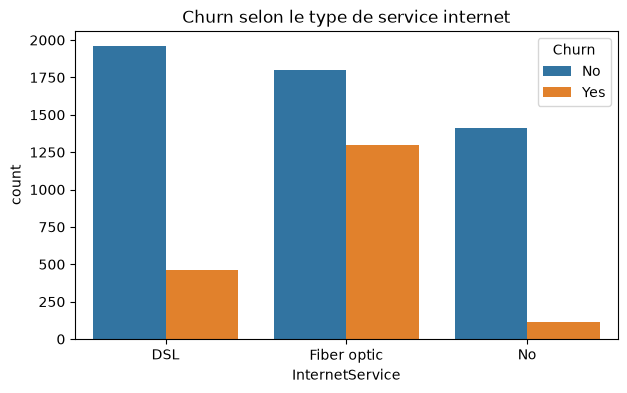

In [14]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn selon le type de service internet')
plt.show()

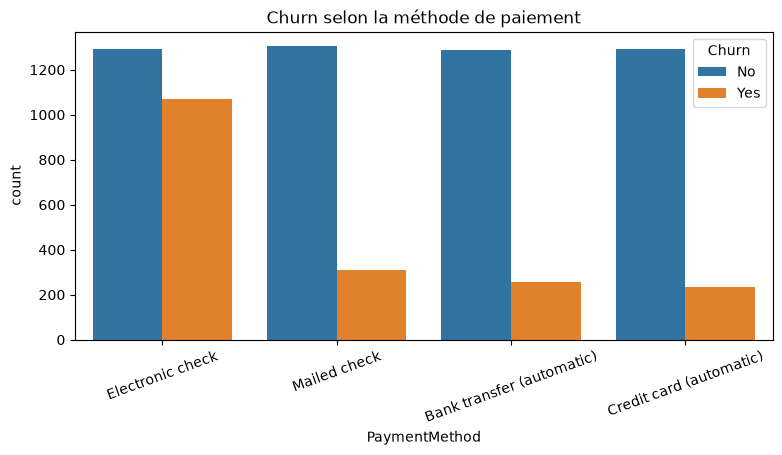

In [15]:
plt.figure(figsize=(9, 4))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title('Churn selon la méthode de paiement')
plt.xticks(rotation=20) #pour éviter que les textes ne se chevauchent
plt.show()

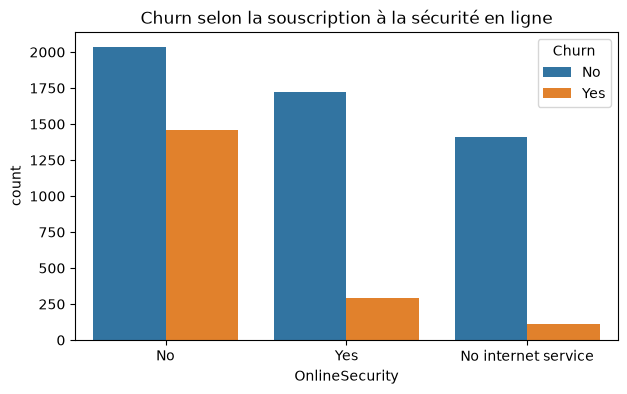

In [16]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='OnlineSecurity', hue='Churn')
plt.title('Churn selon la souscription à la sécurité en ligne')
plt.show()

In [17]:
# On observe que plus tu as pris des services moins tu es susceptible de churn, car tu es plus "engagé"


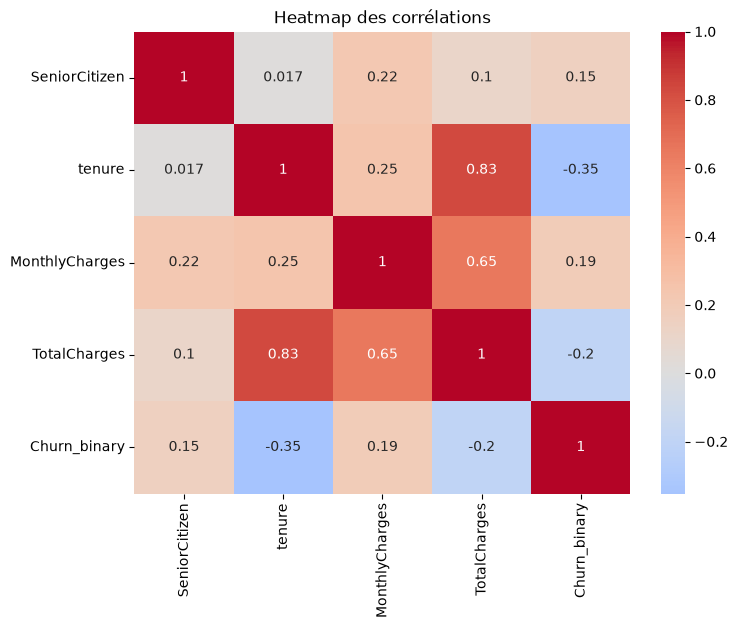

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)
plt.title('Heatmap des corrélations')
plt.show()

In [19]:
#totalcharges et tenure fortement corrélées, monthly charges et total charges aussi, logique

In [20]:
categorical_cols = df.select_dtypes(include='object').columns.drop(['customerID', 'Churn'])

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df.groupby(col)['Churn_binary'].mean().sort_values(ascending=False))


--- gender ---
gender
Female    0.269209
Male      0.261603
Name: Churn_binary, dtype: float64

--- Partner ---
Partner
No     0.329580
Yes    0.196649
Name: Churn_binary, dtype: float64

--- Dependents ---
Dependents
No     0.312791
Yes    0.154502
Name: Churn_binary, dtype: float64

--- PhoneService ---
PhoneService
Yes    0.267096
No     0.249267
Name: Churn_binary, dtype: float64

--- MultipleLines ---
MultipleLines
Yes                 0.286099
No                  0.250442
No phone service    0.249267
Name: Churn_binary, dtype: float64

--- InternetService ---
InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn_binary, dtype: float64

--- OnlineSecurity ---
OnlineSecurity
No                     0.417667
Yes                    0.146112
No internet service    0.074050
Name: Churn_binary, dtype: float64

--- OnlineBackup ---
OnlineBackup
No                     0.399288
Yes                    0.215315
No internet service    0.074050
Name

In [21]:
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
            'TechSupport', 'StreamingTV', 'StreamingMovies']

df['nb_services_souscrits'] = (df[services] == 'Yes').sum(axis=1)

df.groupby('nb_services_souscrits')['Churn_binary'].mean()

nb_services_souscrits
0    0.214060
1    0.457557
2    0.358180
3    0.273703
4    0.223005
5    0.124343
6    0.052817
Name: Churn_binary, dtype: float64

In [22]:
df_model = df.drop(columns=['customerID', 'Churn'])

In [23]:
#on crée une copie pour garder la df originelle clean

In [24]:
df.groupby('InternetService')['Churn_binary'].mean()

InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn_binary, dtype: float64

In [25]:
df_model = pd.get_dummies(df_model, drop_first=True)
df_model.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_binary,nb_services_souscrits,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,2,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,2,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,3,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,0,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [26]:
df_model.shape

(7043, 32)

In [27]:
df_model.dtypes.value_counts()

bool       26
int64       4
float64     2
Name: count, dtype: int64

In [28]:
df_model.to_csv('../data/df_model_ready.csv', index=False)

In [29]:
X = df_model.drop(columns=['Churn_binary'])
y = df_model['Churn_binary']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Taille train : {X_train.shape[0]} lignes")
print(f"Taille test : {X_test.shape[0]} lignes")

Taille train : 5634 lignes
Taille test : 1409 lignes


In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model_baseline = LogisticRegression(max_iter=1000, random_state=42)
model_baseline.fit(X_train_scaled, y_train)
y_pred = model_baseline.predict(X_test_scaled)

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision : {precision_score(y_test, y_pred):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred):.3f}")
print(f"F1-score  : {f1_score(y_test, y_pred):.3f}")

Accuracy  : 0.807
Precision : 0.658
Recall    : 0.567
F1-score  : 0.609


In [33]:
model_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = model_balanced.predict(X_test_scaled)

In [34]:
print(f"Accuracy  : {accuracy_score(y_test, y_pred_balanced):.3f}")
print(f"Precision : {precision_score(y_test, y_pred_balanced):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred_balanced):.3f}")
print(f"F1-score  : {f1_score(y_test, y_pred_balanced):.3f}")

Accuracy  : 0.739
Precision : 0.505
Recall    : 0.783
F1-score  : 0.614


In [35]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

In [36]:
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.3f}")
print(f"F1-score  : {f1_score(y_test, y_pred_rf):.3f}")

Accuracy  : 0.764
Precision : 0.549
Recall    : 0.634
F1-score  : 0.588


In [37]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("churn_prediction")

<Experiment: artifact_location='/home/jules/churn-project/notebooks/mlruns/1', creation_time=1786304173074, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1786304173074, lifecycle_stage='active', name='churn_prediction', tags={}, trace_location=None, workspace='default'>

In [38]:
with mlflow.start_run(run_name="logistic_regression_baseline"):
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("class_weight", "none")
    mlflow.log_param("max_iter", 1000)
    
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred))
    mlflow.log_metric("precision", precision_score(y_test, y_pred))
    mlflow.log_metric("recall", recall_score(y_test, y_pred))
    mlflow.log_metric("f1_score", f1_score(y_test, y_pred))
    
    mlflow.sklearn.log_model(model_baseline, name="model")

In [39]:
with mlflow.start_run(run_name="logistic_regression_balanced"):
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("max_iter", 1000)
    
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_balanced))
    mlflow.log_metric("precision", precision_score(y_test, y_pred_balanced))
    mlflow.log_metric("recall", recall_score(y_test, y_pred_balanced))
    mlflow.log_metric("f1_score", f1_score(y_test, y_pred_balanced))
    
    mlflow.sklearn.log_model(model_balanced, name="model")

In [40]:
with mlflow.start_run(run_name="random_forest"):
    mlflow.log_param("model_type", "RandomForestClassifier")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("n_estimators", 200)
    
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_rf))
    mlflow.log_metric("precision", precision_score(y_test, y_pred_rf))
    mlflow.log_metric("recall", recall_score(y_test, y_pred_rf))
    mlflow.log_metric("f1_score", f1_score(y_test, y_pred_rf))
    
    mlflow.sklearn.log_model(model_rf, name="model")

In [41]:
import os
print(os.getcwd())

/home/jules/churn-project/notebooks


In [42]:
from xgboost import XGBClassifier

# Calcul du ratio de déséquilibre pour XGBoost
ratio = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

In [43]:
print(f"Accuracy  : {accuracy_score(y_test, y_pred_xgb):.3f}")
print(f"Precision : {precision_score(y_test, y_pred_xgb):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred_xgb):.3f}")
print(f"F1-score  : {f1_score(y_test, y_pred_xgb):.3f}")

Accuracy  : 0.771
Precision : 0.559
Recall    : 0.647
F1-score  : 0.600


In [44]:
with mlflow.start_run(run_name="xgboost_baseline"):
    mlflow.log_param("model_type", "XGBClassifier")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("scale_pos_weight", round(ratio, 3))
    
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_xgb))
    mlflow.log_metric("precision", precision_score(y_test, y_pred_xgb))
    mlflow.log_metric("recall", recall_score(y_test, y_pred_xgb))
    mlflow.log_metric("f1_score", f1_score(y_test, y_pred_xgb))
    
    mlflow.xgboost.log_model(model_xgb, name="model")

In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_gri

In [46]:
best_xgb = grid_search.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)

print(f"Accuracy  : {accuracy_score(y_test, y_pred_best_xgb):.3f}")
print(f"Precision : {precision_score(y_test, y_pred_best_xgb):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred_best_xgb):.3f}")
print(f"F1-score  : {f1_score(y_test, y_pred_best_xgb):.3f}")

Accuracy  : 0.730
Precision : 0.494
Recall    : 0.813
F1-score  : 0.615


In [47]:
with mlflow.start_run(run_name="xgboost_tuned"):
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_param("model_type", "XGBClassifier_tuned")
    mlflow.log_param("scale_pos_weight", round(ratio, 3))
    
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_best_xgb))
    mlflow.log_metric("precision", precision_score(y_test, y_pred_best_xgb))
    mlflow.log_metric("recall", recall_score(y_test, y_pred_best_xgb))
    mlflow.log_metric("f1_score", f1_score(y_test, y_pred_best_xgb))
    
    mlflow.xgboost.log_model(best_xgb, name="model")

In [48]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

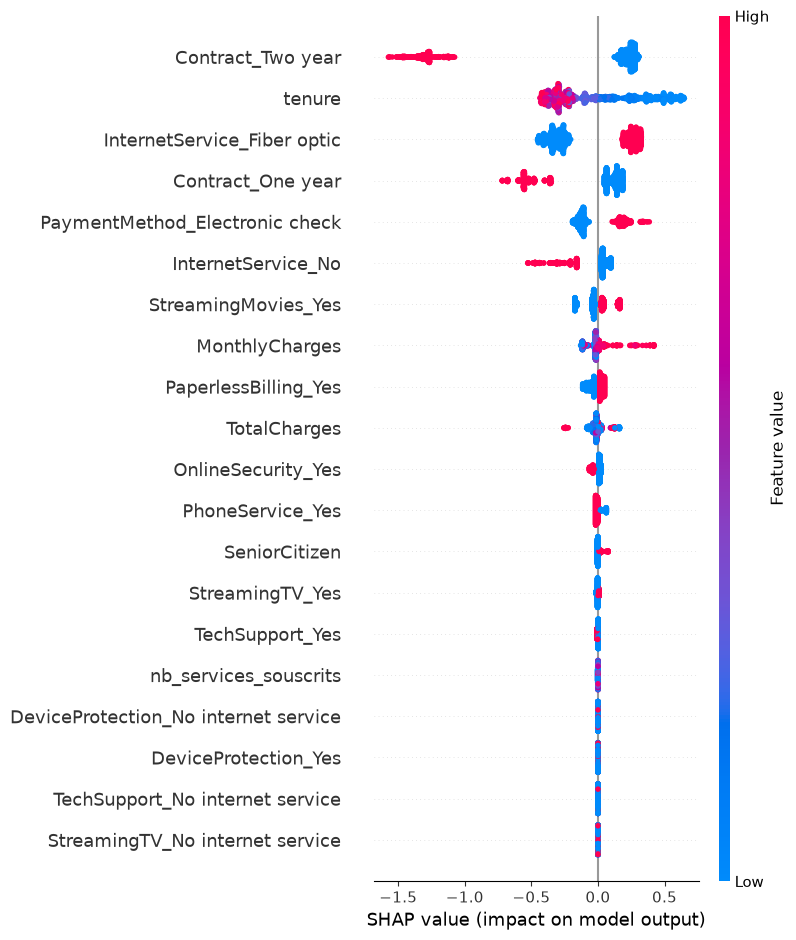

In [49]:
shap.summary_plot(shap_values, X_test)

In [50]:
from src.predict import predict_churn

exemple_client = {
    "gender": "Female", "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "No",
    "tenure": 12, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "No",
    "StreamingMovies": "No", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check", "MonthlyCharges": 70.5, "TotalCharges": 846.0
}

print(predict_churn(exemple_client))

ModuleNotFoundError: No module named 'src'